In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\Farooq_Hussain\Python\Data Analysis\06 - EDA_Netflix\data\netflix_titles.csv", encoding='latin-1')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns")
df.info()
df.describe()

Dataset contains 8807 rows and 12 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [11]:
# Checking duplicate values

df.duplicated().sum()

0

In [13]:
df.dropna(how='all', inplace=True)

df.dropna(subset=['director', 'cast', 'country'], inplace=True)

df.reset_index(drop=True, inplace=True)

print(df.isnull().sum())
print(f"Cleaned dataset shape: {df.shape}")

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          1
duration        3
listed_in       0
description     0
dtype: int64
Cleaned dataset shape: (5336, 12)


In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
1,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
2,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
3,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis NiewÃ¶hner, Milan Peschel,...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
4,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...


In [17]:
# Q1. How many total movies vs TV shows are in the dataset?

type_counts = df['type'].value_counts().reset_index()

print(type_counts)

      type  count
0    Movie   5189
1  TV Show    147


In [23]:
def save_plot(name):
    plt.savefig(fr"D:\Farooq_Hussain\Python\Data Analysis\06 - EDA_Netflix\images/{name}.png", dpi=300, bbox_inches="tight")

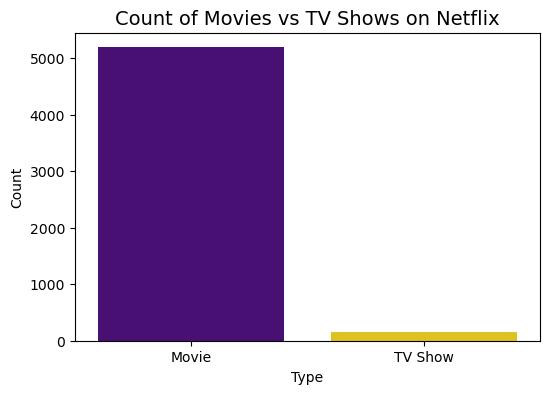

In [25]:
# Q2. Bar chart showing Movies vs TV Shows count.

plt.figure(figsize=(6,4))
sns.countplot(
    x='type',
    hue='type',
    data=df,
    legend=False,
    palette={"Movie": "#4B0082", "TV Show": "#FFD700"}
)
plt.title("Count of Movies vs TV Shows on Netflix", fontsize=14)
plt.xlabel("Type")
plt.ylabel("Count")
save_plot('Count_of_Movies_vs_TV_Shows_on_Netflix')
plt.show()

In [27]:
# Q3. Which are the top 10 countries producing Netflix content?

from collections import Counter

countries = df['country'].dropna().str.split(',').apply(lambda x: [c.strip() for c in x])

# Flattening list of countries
all_countries = [c for sublist in countries for c in sublist]

# Count of occurrences
country_counts = Counter(all_countries)

# Top 10 countries
top_10_countries = country_counts.most_common(10)
print(top_10_countries)

[('United States', 2488), ('India', 940), ('United Kingdom', 485), ('Canada', 295), ('France', 293), ('Germany', 167), ('Spain', 161), ('Japan', 124), ('China', 109), ('Mexico', 101)]


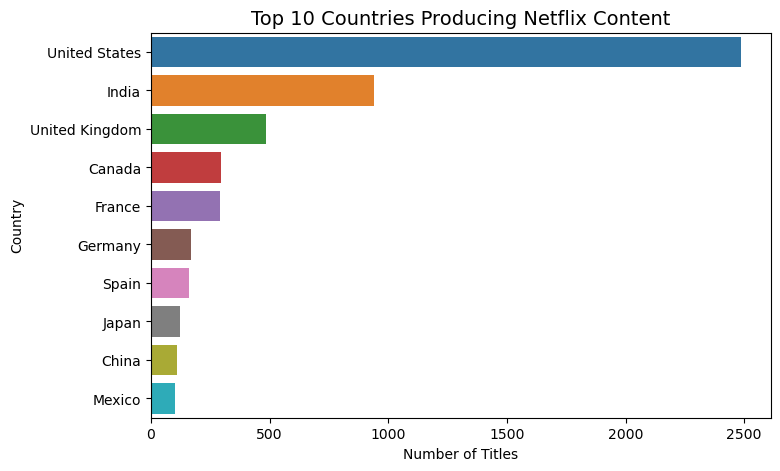

In [29]:
# Q4. Horizontal bar chart of Top 10 countries by content count.

# DataFrame from top 10 countries
top_10_df = pd.DataFrame(top_10_countries, columns=["Country", "Count"])

plt.figure(figsize=(8,5))
sns.barplot(
    data=top_10_df,
    x="Count",
    y="Country",
    hue="Country",
    palette="tab10",
    legend=False
)

plt.title("Top 10 Countries Producing Netflix Content", fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Country")
save_plot('Top_10_Countries_Producing_Netflix_Content')
plt.show()

In [31]:
# Q5. What is the most common genre on Netflix?

# Splitting and cleaning genres
genres = df['listed_in'].dropna().str.split(',').apply(lambda x: [g.strip() for g in x])

# Flattening all genres into a single list
all_genres = [g for sublist in genres for g in sublist]

# Counting genre frequencies
genre_counts = Counter(all_genres)

# Most common genre
most_common_genre = genre_counts.most_common(1)
print("Most common genre on Netflix:", most_common_genre)


Most common genre on Netflix: [('International Movies', 2369)]


In [33]:
# Q6. What is the distribution of content ratings (G, PG, PG-13, TV-MA, etc.)?

rating_counts = df['rating'].value_counts()
print(rating_counts)

rating
TV-MA       1822
TV-14       1214
R            778
PG-13        470
TV-PG        431
PG           275
TV-G          84
TV-Y7         76
TV-Y          76
NR            58
G             40
TV-Y7-FV       3
UR             3
NC-17          2
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


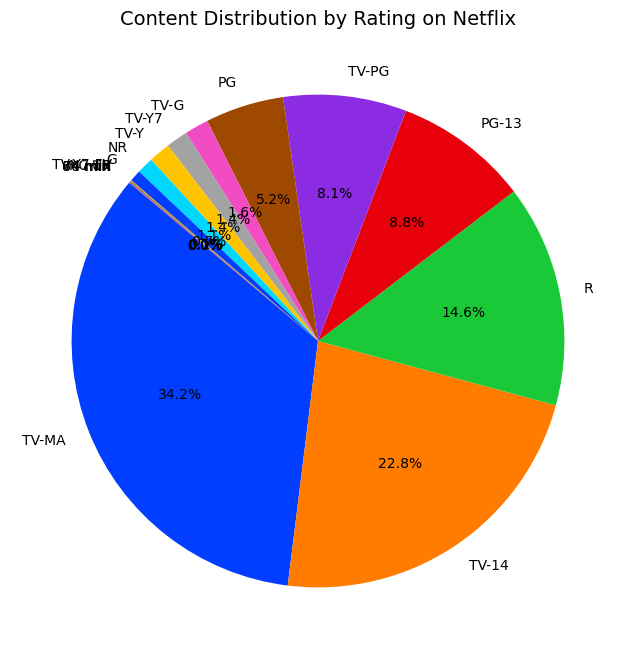

In [35]:
# Q7. Pie chart showing content type distribution by rating.

plt.figure(figsize=(8,8))
colors=sns.color_palette("bright", n_colors=len(rating_counts))

plt.pie(
    rating_counts.values,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)

plt.title("Content Distribution by Rating on Netflix", fontsize=14)
save_plot('Content_Distribution_by_Rating_on_Netflix')
plt.show()

In [37]:
# Q8. Which years saw the highest number of releases?

year_counts = df['release_year'].value_counts().sort_index()
print(year_counts)

# Year with the highest number of releases
max_year = year_counts.idxmax()
max_count = year_counts.max()

print(f"\n\nThe year with the highest releases is {max_year} with {max_count} titles.")

release_year
1942      1
1944      1
1945      1
1946      1
1947      1
       ... 
2017    658
2018    648
2019    519
2020    442
2021    161
Name: count, Length: 72, dtype: int64


The year with the highest releases is 2017 with 658 titles.


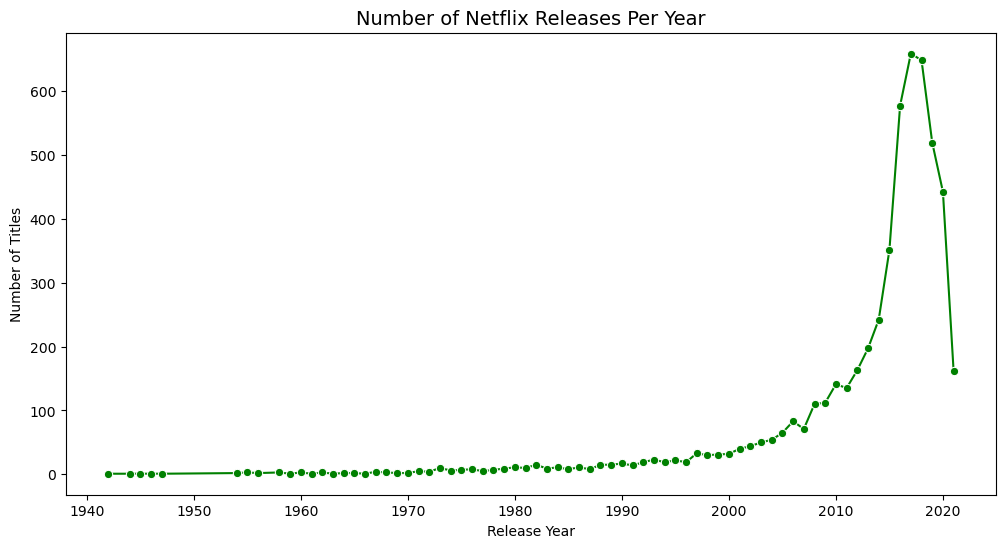

In [39]:
# Q9. Line plot showing number of releases per year.

year_counts = df['release_year'].value_counts().sort_index()

# Converting to DataFrame for seaborn
year_df = year_counts.reset_index()
year_df.columns = ["Year", "Count"]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=year_df,
    x="Year",
    y="Count",
    marker="o",
    color="green"
)

plt.title("Number of Netflix Releases Per Year", fontsize=14)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
save_plot('Number_of_Netflix_Releases_Per_Year')
plt.show()

In [41]:
# Q10. Which directors have the most titles on Netflix?

director_counts = df['director'].value_counts()

# Top 10 directors
top_directors = director_counts.head(10)
print(top_directors)

director
RaÃºl Campos, Jan Suter    18
Marcus Raboy               15
Jay Karas                  14
Cathy Garcia-Molina        13
Jay Chapman                12
Youssef Chahine            12
Martin Scorsese            12
Steven Spielberg           11
Don Michael Paul           10
David Dhawan                9
Name: count, dtype: int64


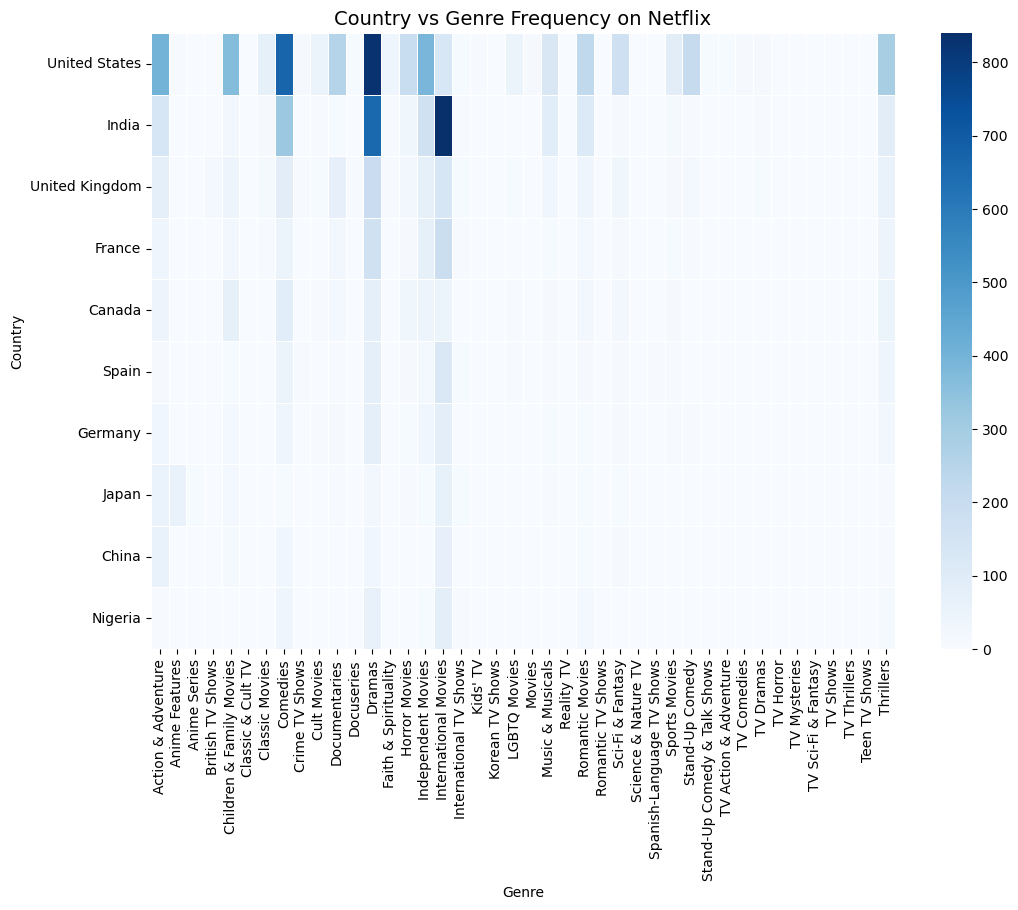

In [43]:
# Q11. Heatmap showing country vs genre frequency.

countries = df['country'].str.split(',').apply(lambda x: [c.strip() for c in x])

genres = df['listed_in'].str.split(',').apply(lambda x: [g.strip() for g in x])

# Creating expanded dataframe of all (country, genre) pairs
expanded_rows = []
for idx in df.index:
    if pd.notna(df.loc[idx, 'country']) and pd.notna(df.loc[idx, 'listed_in']):
        for c in countries[idx]:
            for g in genres[idx]:
                expanded_rows.append((c, g))

expanded_df = pd.DataFrame(expanded_rows, columns=['Country', 'Genre'])

# Creating cross-tab
heatmap_data = pd.crosstab(expanded_df['Country'], expanded_df['Genre'])

# For readability, taking top 10 countries
top_countries = expanded_df['Country'].value_counts().head(10).index
heatmap_data = heatmap_data.loc[top_countries]

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5
)
plt.title("Country vs Genre Frequency on Netflix", fontsize=14)
plt.xlabel("Genre")
plt.ylabel("Country")
save_plot('Country_vs_Genre_Frequency_on_Netflix')
plt.show()

In [ ]:
Final Summary of Insights:

Content Type Distribution - Netflix has significantly more Movies than TV Shows.

Top Countries - The United States produces the most Netflix titles, followed by India, United Kingdom and Japan.
                Regional diversity is visible, but content is heavily skewed toward a handful of countries.

Genres - The most common genres include International Movies, Dramas, and Comedies. Netflix invests heavily
        in international content not just Hollywood.

Content Ratings - The majority of titles fall under TV-MA (mature audiences) and TV-14, showing Netflix’s focus on teen and adult audiences.
                Family-friendly content (G, PG, TV-Y) is comparatively smaller.

Yearly Trends - Releases increased sharply after 2015, with a peak around 2018–2020. Netflix ramped up original productions during this period,
                reflecting its global expansion.

Directors - A few directors have multiple titles, but the majority are one-time contributors. This suggests Netflix works with
            a wide variety of directors.

Country–Genre Patterns - The U.S. dominates in Comedy, Drama, and Documentaries. India shows strong representation in Romantic
                        and Family-oriented films. Japan leads in Anime genres.